Natural Language Interface for Excel
Your Walmart GenAI team will learn to:
1.	Read and interpret Excel using Python
2.	Convert text queries into table summaries and vice versa
3.	Use LLMs to write summaries and create visualizations from Excel data

Real-World Use Case at Walmart
“A manager uploads a sales Excel file. Can an AI agent generate a summary, key trends, and charts — just by asking questions in plain English?”
This is where GenAI + Excel meets practical impact.
 
Step-by-Step: Hands-On GenAI Interface for Excel

1. Environment Setup
pip install pandas openpyxl langchain openai matplotlib seaborn 
python-docx
Also, load your .env file with your OpenAI API Key:
OPENAI_API_KEY=sk-xxxxx

In [ ]:
file_path='./walmart_sales.xlsx'

In [30]:
#2. Read and Interpret Excel using Python
import pandas as pd
# Load Excel
df = pd.read_excel(file_path)
print(df.head())

         Date  Product     Category  Sales    Store
0  2024-01-01   Laptop  Electronics   1200  Store_A
1  2024-01-02       TV  Electronics   3000  Store_B
2  2024-01-03  Shampoo       Health    200  Store_A
3  2024-01-04     Sofa    Furniture   4932  Store_D
4  2024-01-05     Sofa    Furniture   4974  Store_A


3. Table-to-Text Summary with OpenAI

In [32]:
from langchain.llms import OpenAI
from langchain.prompts import PromptTemplate

llm = OpenAI(temperature=0.3)

# Prompt Template
template = """
You are a data analyst. Summarize this table:
{dataframe}
"""

prompt = PromptTemplate.from_template(template)

df_sample = df.head(10).to_string(index=False)
query = prompt.format(dataframe=df_sample)
response = llm.invoke(query)
print("Summary:", response)

Summary: 
This table contains sales data for various products in different categories at different stores on different dates. The products include laptops, TVs, shampoo, sofas, milk, toothpaste, and tables. The categories include electronics, health, furniture, and grocery. The sales amounts range from 1 to 4974. The stores are labeled as Store_A, Store_B, Store_C, and Store_D. The dates range from January 1st, 2024 to January 10th, 2024. 


4. Text-to-Table (Conversational Query to Structured Insight)

In [26]:
query = "Which product sold the most in Store_A?"

context = df[df["Store"] == "Store_A"]

top_product = context.groupby("Product")["Sales"].sum().idxmax()

print("Top product sold in Store_A:", top_product)

Top product sold in Store_A: Sofa


Extend this by integrating with LangChain Tools to allow LLM to trigger such queries dynamically.
 
📈 5. Create Visualizations from Excel Using Python

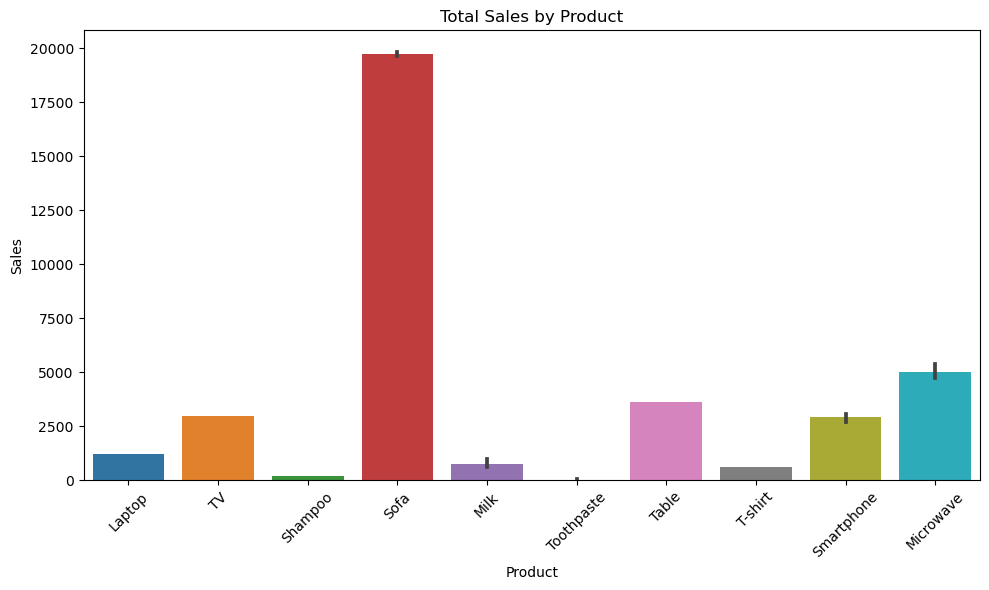

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Product", y="Sales", estimator=sum)
plt.title("Total Sales by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_by_product.png")

In [ ]:
!pip install python-docx

In [39]:
#6. Auto-Generated Report with LLM Summary + Chart

from docx import Document
doc = Document()

doc.add_heading("Walmart Sales Report", 0)
doc.add_paragraph(response)  # From earlier LLM summary
doc.add_picture("sales_by_product.png")

doc.save("walmart_report.docx")

In [ ]:
file_path='./walmart_sales.xlsx'

In [33]:
from langchain.agents import Tool
import pandas as pd

def read_excel(query: str):
    df = pd.read_excel(file_path, sheet_name="SalesData")
    if "total sales" in query.lower():
        return f"Total sales: ₹{df['Sales'].sum()}"
    elif "store" in query.lower():
        return df.groupby("Store")["Sales"].sum().to_string()
    else:
        return df.head().to_string()

excel_tool = Tool(
    name="ExcelReader",
    func=read_excel,
    description="Use to query walmart_sales.xlsx based on user input"
)

In [ ]:
from langchain.llms import OpenAI
from langchain.agents import initialize_agent, AgentType

llm = OpenAI(temperature=0.3)

agent = initialize_agent(
    tools=[excel_tool],
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

agent.run("Show total sales and breakdown by store.")


Install Updated Packages
pip install -U langchain langgraph langchain-openai

In [ ]:
pip install -U langchain langgraph langchain-openai

In [7]:
from pprint import pprint
#Step 5: Generate Report from Prompt
summary_prompt = f"""
You are a Walmart reporting assistant. Create a business summary based on this:
{read_excel("summary")}
"""

summary = llm.invoke(summary_prompt)
pprint(summary)

('\n'
 'Business Summary for Walmart:\n'
 '\n'
 'In the first week of January 2024, Walmart saw a total sales of $14,306 '
 'across four of its stores - Store_A, Store_B, Store_C, and Store_D. The '
 'highest sales were recorded at Store_A with a total of $6,174, followed by '
 'Store_D with $4,932. Electronics was the top-selling category with a total '
 'sales of $4,200, followed by Furniture with $9,906. The top-selling products '
 'were TV and Laptop, with sales of $3,000 and $1,200 respectively. The lowest '
 'sales were recorded in the Health category with a total of $200. Overall, '
 'Walmart had a successful start to the new year with strong sales in multiple '
 'categories. ')


In [26]:
from pymilvus import connections

connections.connect(
    uri=cluster_endpoint,
    token=api_key,
    secure=True
)
print("✅ Connected to Milvus Cloud!")

✅ Connected to Milvus Cloud!


In [27]:
from pymilvus import connections, Collection, FieldSchema, CollectionSchema, DataType, Index
from sentence_transformers import SentenceTransformer

# ✅ Connect to Milvus
connections.connect(
    alias="default",
    uri=cluster_endpoint,
    token=api_key,
    secure=True
)

# ✅ Load Sentence Transformer
model = SentenceTransformer("all-MiniLM-L6-v2")

# ✅ Create collection schema
fields = [
    FieldSchema(name="id", dtype=DataType.INT64, is_primary=True, auto_id=False),
    FieldSchema(name="Date", dtype=DataType.VARCHAR, max_length=64),
    FieldSchema(name="Product", dtype=DataType.VARCHAR, max_length=512),
    FieldSchema(name="Category", dtype=DataType.VARCHAR, max_length=128),
    FieldSchema(name="Sales", dtype=DataType.FLOAT),
    FieldSchema(name="Store", dtype=DataType.VARCHAR, max_length=128),
    FieldSchema(name="embedding", dtype=DataType.FLOAT_VECTOR, dim=384)
]

schema = CollectionSchema(fields, description="Walmart sales with semantic search")

# ✅ Create or get collection
collection_name = "walmart_sales"

from pymilvus import utility

if utility.has_collection(collection_name):
    Collection(collection_name).drop()

collection = Collection(name=collection_name, schema=schema)


# ✅ Insert data
text = "Store_A had highest sales last month. Recommend restocking."
embedding = model.encode(text).tolist()

collection.insert([
    [1],                         # id
    ["2023-10-01"],              # Date
    ["Laptop"],                  # Product
    ["Electronics"],             # Category
    [1200.0],                    # Sales
    ["Store_A"],                 # Store
    [embedding]                  # Embedding
])

# ✅ Create vector index
index = Index(
    collection=collection,
    field_name="embedding",
    index_params={"index_type": "IVF_FLAT", "metric_type": "COSINE", "params": {"nlist": 128}}
)

# ✅ Load collection
collection.load()

# ✅ Run semantic search
query_embedding = model.encode("What were the sales trends last month?").tolist()
results = collection.search(
    data=[query_embedding],
    anns_field="embedding",
    param={"metric_type": "COSINE", "params": {"nprobe": 10}},
    limit=5,
    output_fields=["Date", "Product", "Category", "Sales", "Store"]
)

# ✅ Display results
print("\n🔍 Search Results:")
for result in results[0]:
    print(f"Score: {result.score:.3f} | Date: {result.entity.get('Date')}, "
          f"Product: {result.entity.get('Product')}, Category: {result.entity.get('Category')}, "
          f"Sales: {result.entity.get('Sales')}, Store: {result.entity.get('Store')}")

# ✅ Clean up
collection.release()
connections.disconnect(alias="default")


🔍 Search Results:
Score: 0.603 | Date: 2023-10-01, Product: Laptop, Category: Electronics, Sales: 1200.0, Store: Store_A


In [2]:
from openai import AzureOpenAI
import openai
import os

client = AzureOpenAI(
    api_key=api_key,
    azure_endpoint=api_base,
    azure_deployment="gpt-4o",
    api_version="2024-12-01-preview"
)

In [3]:
#  Simple chat completion request
response = client.chat.completions.create(
    model="gpt-4o",
    messages=[
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": "What's the difference between AI and AGI?"}
    ]
)

# Display the response
print(response.choices[0].message.content)

The difference between **AI (Artificial Intelligence)** and **AGI (Artificial General Intelligence)** lies in scope, capability, and purpose. Here’s a breakdown:

### **AI (Artificial Intelligence):**
- **Definition**: AI refers to computer systems or algorithms designed to perform specific tasks autonomously or mimic aspects of human intelligence, such as problem-solving, decision-making, or pattern recognition.
- **Scope**: AI systems are typically **narrow** or **specialized**—they excel at specific tasks but lack the ability to generalize their knowledge to unrelated problems.
  - Examples: 
    - Language translation (e.g., Google Translate).
    - Voice assistants (e.g., Siri, Alexa).
    - Image recognition (e.g., facial recognition software).
    - Recommendation systems (e.g., Netflix or Spotify recommendations).
- **Capabilities**: AI operates based on training data, algorithms, and predefined rules. It doesn’t possess human-like understanding or reasoning beyond its programm

In [4]:
from langchain_openai import AzureChatOpenAI

model = AzureChatOpenAI(
    api_key=api_key,
    azure_endpoint=api_base,
    azure_deployment="gpt-4o",
    api_version="2024-12-01-preview"
)
model.invoke("Hello, world!")

AIMessage(content='Hello, world! 🌍👋 How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 16, 'prompt_tokens': 11, 'total_tokens': 27, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BraR4FdW5Cg7kkOYDGmqVtqspi15y', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 

In [9]:
from langchain_core.messages import HumanMessage, SystemMessage

messages = [
    SystemMessage("Translate the following from English into Hindi"),
    HumanMessage("Hello Surendra Panpaliya !"),
]
model.invoke(messages)

AIMessage(content='नमस्ते सुरेंद्र पानपालिया!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 25, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-11-20', 'system_fingerprint': 'fp_ee1d74bde0', 'id': 'chatcmpl-BraVEUkdmnB2WkySTfQHPZoyeh3Wd', 'service_tier': None, 'prompt_filter_results': [{'prompt_index': 0, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'jailbreak': {'filtered': False, 'detected': False}, 'self_harm': {'filtered': False, 'severity': 'safe'}, 'sexual': {'filtered': False, 'severity': 'safe'}, 'violence': {'filtered': False, 'severity': 'safe'}}}], 'finish_reason': 'stop', 'logprobs': None, 'content_filter_results': {'hate': {'filtered': False, 'severity': 'safe'}, 'self_har

In [10]:
model.invoke("Hello Surendra Panpaliya")

model.invoke([{"role": "user", "content": "Hello Surendra Panpaliya"}])

model.invoke([HumanMessage("Hello Surendra Panpaliya")])

for token in model.stream(messages):
    print(token.content, end="|")

||न|म|स्त|े| सुर|ेंद्र| प|न|प|ल|िया|!||

In [7]:
for token in model.stream(messages):
    print(token.content, end="|")

||स|ुप|्र|भ|ात| एज|ेंट|िक| ए|आई|!||

In [11]:
from langchain_core.prompts import ChatPromptTemplate

system_template = "Translate the following from English into {language}"

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template), ("user", "{text}")]
)


prompt = prompt_template.invoke({"language": "Hindi", "text": "hi!"})

print(prompt)

prompt.to_messages()

response = model.invoke(prompt)
print(response.content)

messages=[SystemMessage(content='Translate the following from English into Hindi', additional_kwargs={}, response_metadata={}), HumanMessage(content='hi!', additional_kwargs={}, response_metadata={})]
नमस्ते!


In [ ]:
file_path='./walmart_sales.xlsx'

In [14]:
#2. Read and Interpret Excel using Python
import pandas as pd
# Load Excel
df = pd.read_excel(file_path)
print(df.head())

         Date  Product     Category  Sales    Store
0  2024-01-01   Laptop  Electronics   1200  Store_A
1  2024-01-02       TV  Electronics   3000  Store_B
2  2024-01-03  Shampoo       Health    200  Store_A
3  2024-01-04     Sofa    Furniture   4932  Store_D
4  2024-01-05     Sofa    Furniture   4974  Store_A


In [31]:
from langchain_openai import AzureChatOpenAI
from langchain_core.prompts import ChatPromptTemplate

llm = AzureChatOpenAI(
    api_key=api_key,
    azure_endpoint=api_base,
    azure_deployment="gpt-4o",
    api_version="2024-12-01-preview",
    temperature=0.3
)

# Prompt Template
system_template = """
You are a data analyst. Summarize this table:
{dataframe}
"""

prompt_template = ChatPromptTemplate.from_messages(
    [("system", system_template),]
)

df_sample = df.head(10).to_string(index=False)

query = prompt_template.format(dataframe=df_sample)
response = llm.invoke(query)
print("Summary:", response.content)

#for summary in response:
#    print(summary[1])

Summary: The table summarizes sales data for various products across different categories and stores over a 10-day period in January 2024. Here's a breakdown:

1. **Categories**:
   - **Electronics**: Includes sales of a laptop ($1,200) and a TV ($3,000).
   - **Health**: Includes shampoo ($200) and toothpaste ($1).
   - **Furniture**: Dominates sales with sofas ($4,932, $4,974, $4,912) and a table ($3,621).
   - **Grocery**: Includes milk ($207, $235).

2. **Stores**:
   - **Store_A**: Sold a laptop, shampoo, sofa, milk, and toothpaste, with sales ranging from $1 to $4,974.
   - **Store_B**: Sold a TV and a table, with sales of $3,000 and $3,621, respectively.
   - **Store_C**: Sold a sofa for $4,912.
   - **Store_D**: Sold a sofa and milk, with sales of $4,932 and $235, respectively.

3. **Top Performing Category**: Furniture had the highest sales, with multiple high-value transactions (sofa and table).

4. **Top Performing Store**: **Store_A** had the most diverse product range and 

In [27]:
query = "Which product sold the most in Store_A?"

context = df[df["Store"] == "Store_A"]

top_product = context.groupby("Product")["Sales"].sum().idxmax()

print("Top product sold in Store_A:", top_product)

Top product sold in Store_A: Sofa


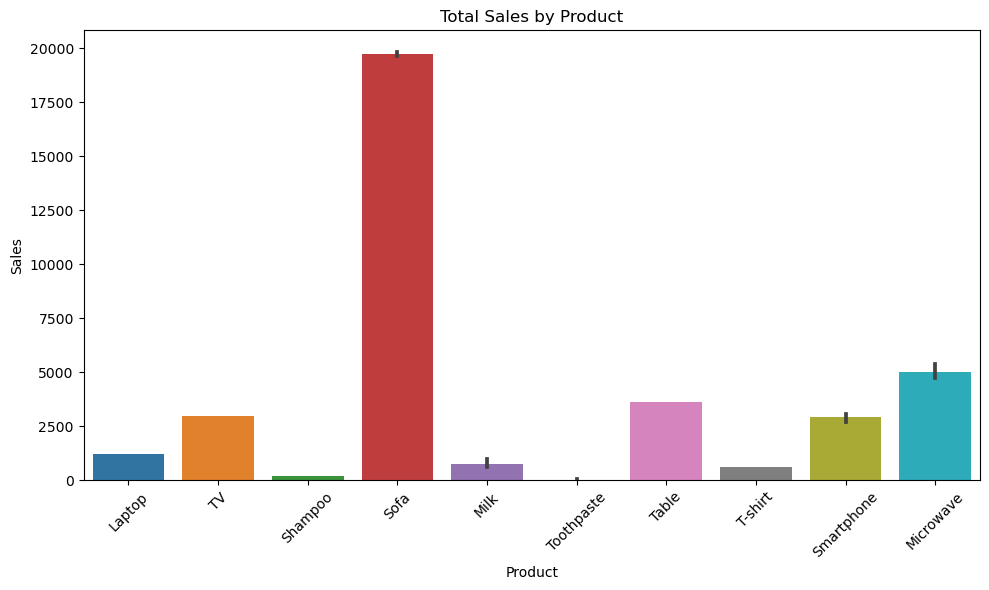

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Product", y="Sales", estimator=sum)
plt.title("Total Sales by Product")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("sales_by_product.png")

In [67]:
#6. Auto-Generated Report with LLM Summary + Chart

from docx import Document
doc = Document()

doc.add_heading("Walmart Sales Report", 0)
doc.add_paragraph(response.text())  # From earlier LLM summary
doc.add_picture("sales_by_product.png")

doc.save("walmart_report1.docx")

In [34]:
from langchain.agents import Tool
import pandas as pd

def read_excel(query: str):
    df = pd.read_excel(file_path, sheet_name="SalesData")
    if "total sales" in query.lower():
        return f"Total sales: ₹{df['Sales'].sum()}"
    elif "store" in query.lower():
        return df.groupby("Store")["Sales"].sum().to_string()
    else:
        return df.head().to_string()

excel_tool = Tool(
    name="ExcelReader",
    func=read_excel,
    description="Use to query walmart_sales.xlsx based on user input"
)

In [ ]:
from langchain.agents import initialize_agent, AgentType
from langchain_openai import AzureChatOpenAI
#from langchain_core.prompts import ChatPromptTemplate

llm = AzureChatOpenAI(
    api_key=api_key,
    azure_endpoint=api_base,
    azure_deployment="gpt-4o",
    api_version="2024-12-01-preview",
    temperature=0.3
)

agent = initialize_agent(
    tools=[excel_tool],
    llm=llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

agent.run("Show total sales and breakdown by store.")

In [63]:
from pprint import pprint
#Step 5: Generate Report from Prompt
summary_prompt = f"""
You are a Walmart reporting assistant. Create a business summary based on this:
{read_excel("summary")}
"""

summary = llm.invoke(summary_prompt)

summary.pretty_print()

================================== Ai Message ==================================

**Walmart Business Summary**

**Date Range:** January 1, 2024 - January 5, 2024  
**Overview:** During the specified period, Walmart recorded sales across multiple product categories, including Electronics, Health, and Furniture. The data highlights sales performance across four stores: Store_A, Store_B, and Store_D.

---

### **Sales Breakdown by Category:**
1. **Electronics:**  
   - **Laptop**: $1,200 (Store_A)  
   - **TV**: $3,000 (Store_B)  
   - **Total Electronics Sales:** $4,200  

2. **Health:**  
   - **Shampoo**: $200 (Store_A)  
   - **Total Health Sales:** $200  

3. **Furniture:**  
   - **Sofa**: $4,932 (Store_D)  
   - **Sofa**: $4,974 (Store_A)  
   - **Total Furniture Sales:** $9,906  

---

### **Sales Breakdown by Store:**
1. **Store_A:**  
   - Laptop: $1,200  
   - Shampoo: $200  
   - Sofa: $4,974  
   - **Total Sales:** $6,374  

2. **Store_B:**  
   - TV: $3,000  
   - **Total Sa